# PINN Landslide Model v8 — Enhanced Preprocessing & Statistical Analysis

Changes from v7:
- `preprocessing_v2` with dropped-row reporting
- Log-transform skewed distance/area features
- Percentile-based outlier clipping (1st/99th)
- Feature correlation check
- New model save path (`v8/`) to preserve v7 weights

Post-training analyses:
- Calibration plot + Brier score
- Precision-Recall curve + AUPR
- Success rate curve
- Landslide density by susceptibility class
- Intermediate parameter correlation matrix
- Geotechnical parameters by soil type (vs literature)
- Cross-fold stability
- Fold ensemble uncertainty map

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from py_files.helpers import set_seed
set_seed(42)

In [2]:
MODEL_SAVE_PATH = "/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v8"
FILE_PATH = "~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_17_training_v3_contri.gpkg"
BASE_PATH = "~/Documents/ml-prep/ML-PREP-2025/learn/data"

import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import tensorflow as tf
import contextily as cx

from py_files.data import (
    preprocessing_v2, dataframe_to_dataset,
    log_transform_skewed, clip_outliers, check_feature_correlation,
)
from py_files.train_rainfall_v3 import train_model_rainfall_v3
from py_files.helpers import add_soil_texture_index, SOIL_TEXTURE_TO_IDX
from py_files.metrics import (
    plot_susceptibility_map, plot_calibration, plot_precision_recall,
    success_rate_curve, landslide_density_by_class,
    plot_intermediate_correlation, plot_geotech_by_soil_type,
    plot_fold_stability, fold_ensemble_uncertainty,
    plot_auc, plot_confusion_matrix,
    false_positive_analysis, plot_fp_vs_tp_distributions,
    fp_tp_statistical_tests, plot_fp_map, plot_fp_susceptibility_histogram,
    classify_predictions,
)

## 1. Load & Preprocess (enhanced)

In [4]:
COLUMNS_DROP = [
    'Landslide1', 'descriptio', 'sus_pinn_ground truth', 'ds',
    'cohesion', 'internal_friction', 'sus_pinn_landslide',
    'confusion', 'landslide_preds', 'landslide_probability',
    'Lithology', 'LITHO', 'Geomorphology', 'LITHODESC',
    'LITHO_2', 'LITHODESC_2', 'value',
]

df = gpd.read_file(FILE_PATH)
print(f"Raw dataset: {len(df)} rows")
df, columns, numeric_cols = preprocessing_v2(df, columns_drop=COLUMNS_DROP)

Raw dataset: 60594 rows
  Preprocessing report:
    Starting rows:        60594  (landslide=6820)
    Dropped (Slope < 10): 0  (landslide=0)
    Columns with nulls:   {'type': np.int64(1032)}
    Dropped (NaN):        1032
    Final rows:           59562  (landslide=6615)


In [5]:
# Feature correlation check — flag pairs with |r| > 0.9
corr_pairs = check_feature_correlation(df, numeric_cols, threshold=0.9)

  Highly correlated pairs (|r| > 0.9):
 feature_1  feature_2  correlation
Distrv_min distrd_min     0.999643


In [6]:
# Log-transform right-skewed features (distances, contributing area)
# IMPORTANT: exclude all features used directly by physics layers (Mohr-Coulomb / Newmark)
# These need real physical units — log-transforming them breaks FOS/displacement equations.
PHYSICS_FEATURES = {
    'Slope_mean', 'BUK_mean', 'PGA2_max',        # already excluded in v7
    'Prc_mean', 'ContributingFactor_mean',         # wetness layer inputs
    'SoilThc_mean',                                # soil thickness -> FOS
    'LULC_majority',                               # categorical-like
}
df, transformed_cols = log_transform_skewed(
    df, numeric_cols, skew_threshold=1.0, exclude=PHYSICS_FEATURES
)
print(f"\nTransformed columns: {transformed_cols}")

    log1p(NDVI_mean)  skew was -1.67
    log1p(DistFlt_min)  skew was 1.31
    log1p(Distrv_min)  skew was 1.87
    log1p(distrd_min)  skew was 1.87

Transformed columns: ['NDVI_mean', 'DistFlt_min', 'Distrv_min', 'distrd_min']


In [7]:
# Outlier clipping at 1st/99th percentiles
# Same exclusion: physics-input features must keep their real values
outlier_cols = [c for c in numeric_cols if c not in PHYSICS_FEATURES]
df = clip_outliers(df, outlier_cols, lower_pct=1, upper_pct=99)

    Clipped Clay_mean: [313.0000, 432.9952] (1183 values)
    Clipped Sand_mean: [282.0000, 388.8641] (1185 values)
    Clipped Silt_mean: [229.0000, 358.0000] (1176 values)
    Clipped NDVI_mean: [0.3996, 0.6247] (1192 values)
    Clipped Est_mean: [-0.9935, 0.9872] (1189 values)
    Clipped Nrt_mean: [-0.9926, 0.9918] (1192 values)
    Clipped HorCurv_mean: [-0.0925, 0.0606] (1192 values)
    Clipped VertCurv_mean: [-0.0316, 0.0122] (1190 values)
    Clipped Elev_mean: [74.2448, 1939.0204] (1192 values)
    Clipped DistFlt_min: [2.3979, 9.9906] (1172 values)
    Clipped TWI_mean: [0.8862, 7.1123] (1192 values)
    Clipped Distrv_min: [0.0000, 7.8591] (596 values)
    Clipped distrd_min: [0.0000, 7.8570] (596 values)


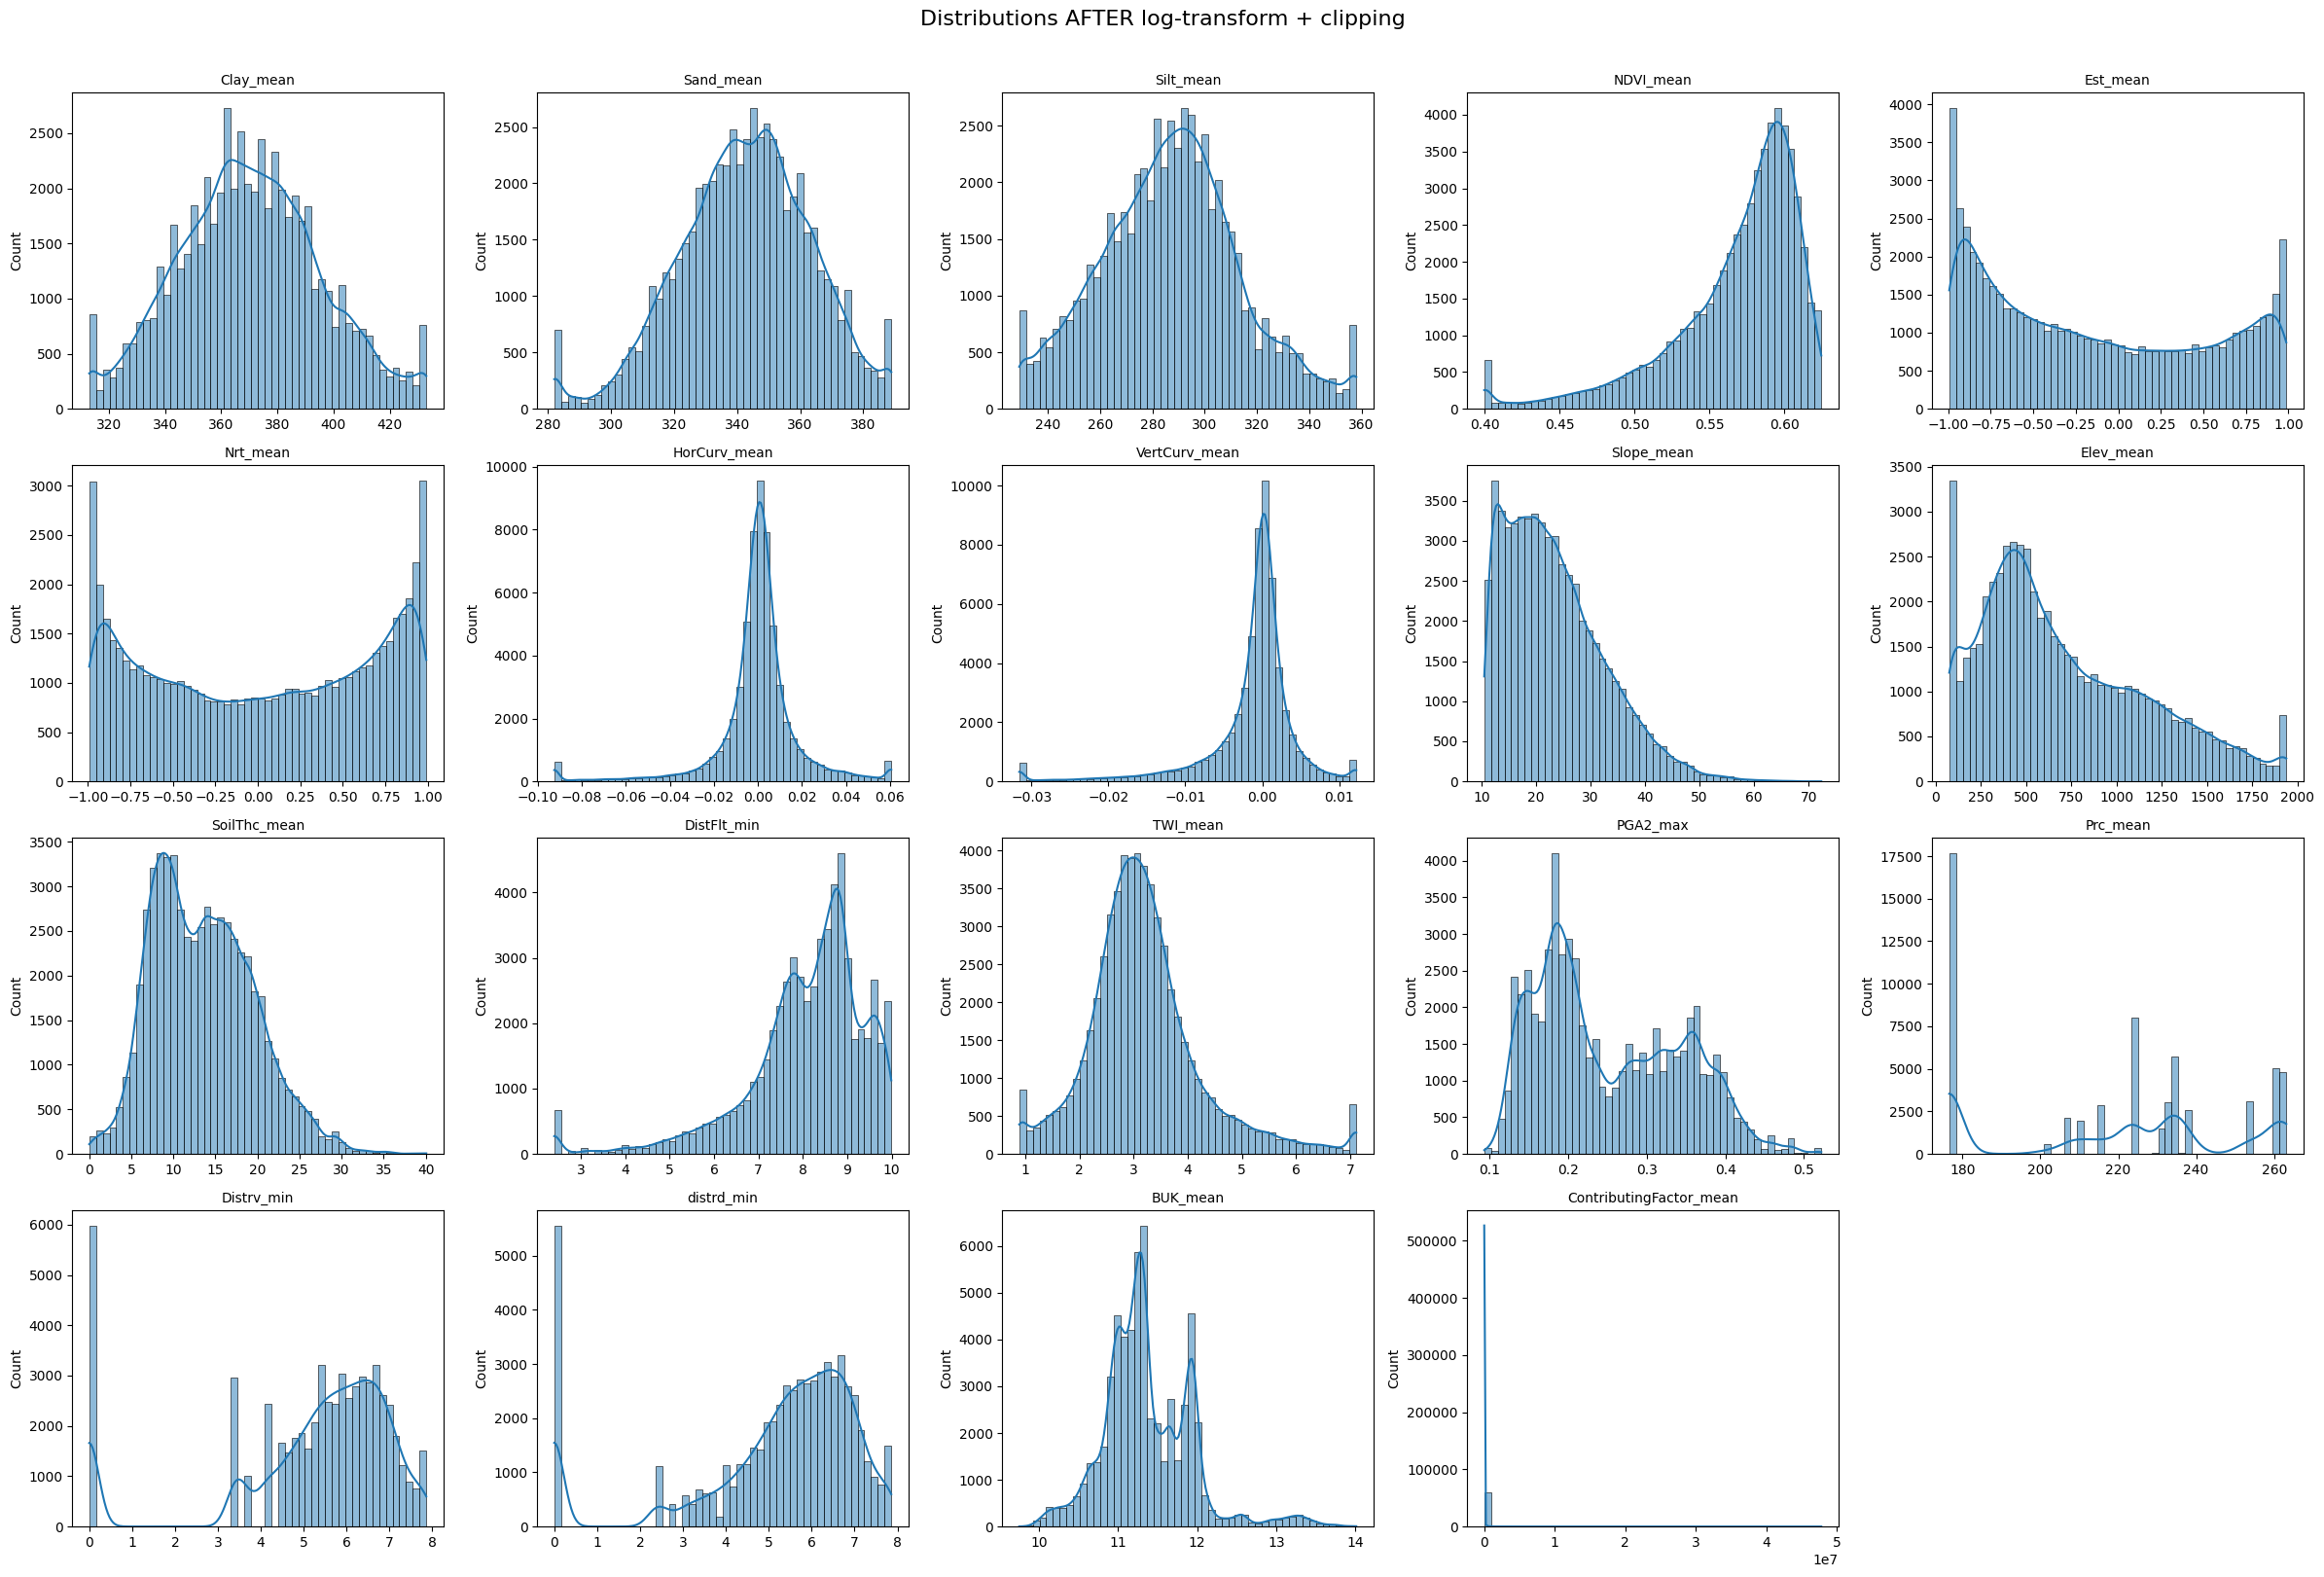

In [8]:
# Distribution plots after preprocessing enhancements
plot_cols = [c for c in numeric_cols if c not in ('LULC_majority', 'PGA1_max')]
n_cols = len(plot_cols)
n_rows = (n_cols + 4) // 5
fig, axes = plt.subplots(n_rows, 5, figsize=(24, 4 * n_rows))
fig.suptitle("Distributions AFTER log-transform + clipping", fontsize=16, y=1.01)
axes_flat = axes.flatten()
for i, col in enumerate(plot_cols):
    ax = axes_flat[i]
    sns.histplot(df[col], kde=True, ax=ax, bins=50)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
for j in range(len(plot_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.tight_layout()
plt.show()

In [9]:
# Add soil texture index and prepare for training
df = add_soil_texture_index(df[columns].copy())
df.columns

Index(['Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean', 'Est_mean',
       'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean', 'Elev_mean',
       'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean', 'PGA2_max',
       'Prc_mean', 'Distrv_min', 'distrd_min', 'BUK_mean', 'landslide', 'type',
       'ContributingFactor_mean', 'soil_texture', 'soil_texture_idx'],
      dtype='object')

## 2. Train Model (v8 path)

2026-05-05 09:49:49.079648: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-05 09:49:49.253392: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-05 09:49:49.594907: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-05 09:49:50.270109: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-05 09:49:51.623374: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200
373/373 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - final_head_accuracy: 0.6940 - final_head_auc: 0.6435 - final_head_binary_io_u: 0.4158 - final_head_loss: 1.1321 - loss: 2.1418 - physics_prob_auc: 0.6387 - physics_prob_loss: 3.3655 - val_final_head_accuracy: 0.6094 - val_final_head_auc: 0.7215 - val_final_head_binary_io_u: 0.3764 - val_final_head_loss: 0.9684 - val_loss: 2.3543 - val_physics_prob_auc: 0.7185 - val_physics_prob_loss: 4.6069
Epoch 2/200
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - final_head_accuracy: 0.8511 - final_head_auc: 0.7231 - final_head_binary_io_u: 0.5196 - final_head_loss: 0.7483 - loss: 1.0963 - physics_prob_auc: 0.6833 - physics_prob_loss: 1.1602 - val_final_head_accuracy: 0.8738 - val_final_head_auc: 0.7962 - val_final_head_binary_io_u: 0.5672 - val_final_head_loss: 0.5490 - val_loss: 0.7050 - val_physics_prob_auc: 0.7504 - val_physics_prob_loss: 0.5167
Epoch 3/200
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - final_head_accuracy: 0.8746 -

2026-05-05 09:50:21.351033: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200
373/373 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - final_head_accuracy: 0.6838 - final_head_auc: 0.6776 - final_head_binary_io_u_1: 0.4152 - final_head_loss: 1.1828 - loss: 2.2909 - physics_prob_auc: 0.6751 - physics_prob_loss: 3.6935 - val_final_head_accuracy: 0.6381 - val_final_head_auc: 0.7275 - val_final_head_binary_io_u_1: 0.3965 - val_final_head_loss: 0.9190 - val_loss: 2.1870 - val_physics_prob_auc: 0.7276 - val_physics_prob_loss: 4.1738
Epoch 2/200
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - final_head_accuracy: 0.8473 - final_head_auc: 0.6790 - final_head_binary_io_u_1: 0.5002 - final_head_loss: 0.7725 - loss: 1.1606 - physics_prob_auc: 0.6289 - physics_prob_loss: 1.2938 - val_final_head_accuracy: 0.8749 - val_final_head_auc: 0.7431 - val_final_head_binary_io_u_1: 0.5263 - val_final_head_loss: 0.5633 - val_loss: 0.7165 - val_physics_prob_auc: 0.6619 - val_physics_prob_loss: 0.5065
Epoch 3/200
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - final_head_accuracy: 

2026-05-05 09:51:34.586926: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200
373/373 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - final_head_accuracy: 0.8245 - final_head_auc: 0.6389 - final_head_binary_io_u_3: 0.4817 - final_head_loss: 0.8478 - loss: 1.3799 - physics_prob_auc: 0.6369 - physics_prob_loss: 1.7737 - val_final_head_accuracy: 0.6523 - val_final_head_auc: 0.7309 - val_final_head_binary_io_u_3: 0.4039 - val_final_head_loss: 0.9081 - val_loss: 2.1143 - val_physics_prob_auc: 0.7252 - val_physics_prob_loss: 3.9978
Epoch 2/200
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - final_head_accuracy: 0.8744 - final_head_auc: 0.7616 - final_head_binary_io_u_3: 0.5364 - final_head_loss: 0.7373 - loss: 1.0710 - physics_prob_auc: 0.6945 - physics_prob_loss: 1.1123 - val_final_head_accuracy: 0.8874 - val_final_head_auc: 0.7977 - val_final_head_binary_io_u_3: 0.5694 - val_final_head_loss: 0.5477 - val_loss: 0.6792 - val_physics_prob_auc: 0.7256 - val_physics_prob_loss: 0.4352
Epoch 3/200
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - final_head_accuracy: 

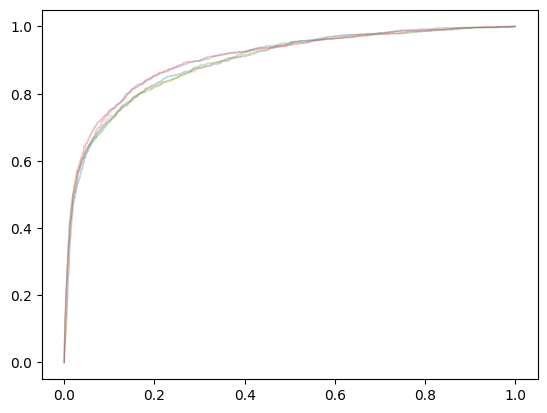

In [10]:
from py_files.LandslideRainfall_v3 import numeric_cols as v3_numeric_cols

train_model_rainfall_v3(
    df,
    numeric_cols + ["soil_texture_idx"],
    ['type'],
    columns + ['soil_texture_idx'],
    "PGA2_max",
    MODEL_SAVE_PATH,
)

## 3. Load Best Fold Model & Prepare Validation Data

In [11]:
from tensorflow.keras.models import load_model
from py_files.GallenModel_v1 import NewmarkActivation

model = load_model(
    f"{MODEL_SAVE_PATH}/fold-3-model-v3.keras",
    custom_objects={"NewmarkActivation": NewmarkActivation},
)

In [12]:
# Reload full dataset for validation (no outlier removal on validation)
validation_df = gpd.read_file(FILE_PATH)
validation_df, columns, numeric_cols = preprocessing_v2(
    validation_df, columns_drop=COLUMNS_DROP
)
validation_df = add_soil_texture_index(validation_df)
validation_ds = dataframe_to_dataset(
    validation_df[columns + ['soil_texture_idx']], shuffle=False, batch_size=128
)
y_true = validation_df['landslide'].values

  Preprocessing report:
    Starting rows:        60594  (landslide=6820)
    Dropped (Slope < 10): 0  (landslide=0)
    Columns with nulls:   {'type': np.int64(1032)}
    Dropped (NaN):        1032
    Final rows:           59562  (landslide=6615)


## 4. Susceptibility Predictions & Standard Metrics

In [ ]:
susceptibility = model.predict(validation_ds)["final_head"].flatten()
print(susceptibility)
plot_susceptibility_map(validation_df, susceptibility, "PINN v8")

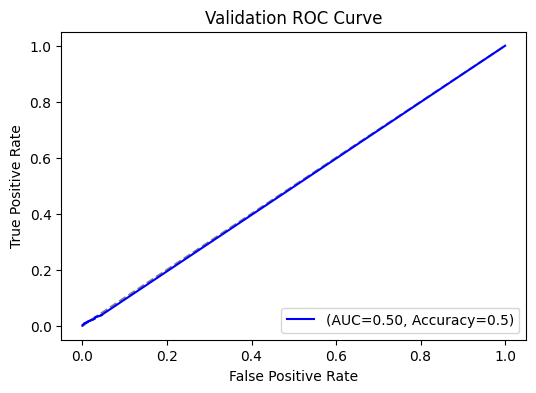

In [ ]:
# ROC / AUC
plot_auc(y_true, susceptibility)

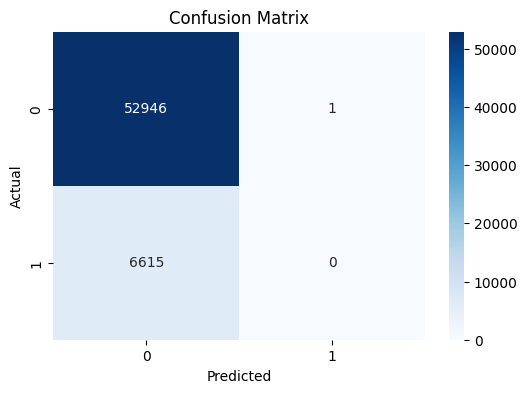

In [ ]:
# Confusion matrix
plot_confusion_matrix(susceptibility, y_true)

## 5. New Statistical Analyses

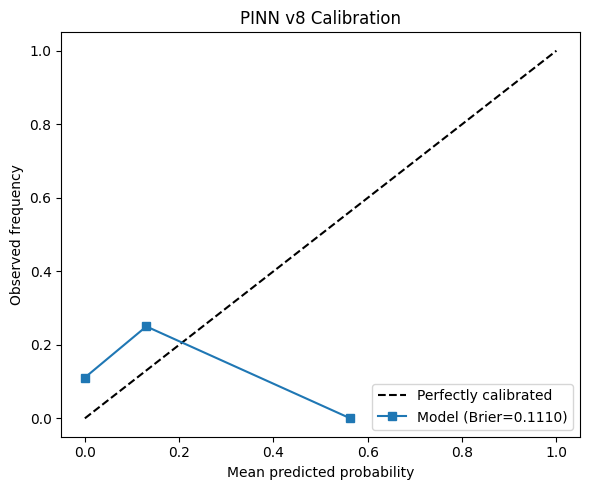

Brier Score: 0.1110


In [ ]:
# 5a. Calibration plot + Brier score
brier = plot_calibration(y_true, susceptibility, title="PINN v8 Calibration")
print(f"Brier Score: {brier:.4f}")

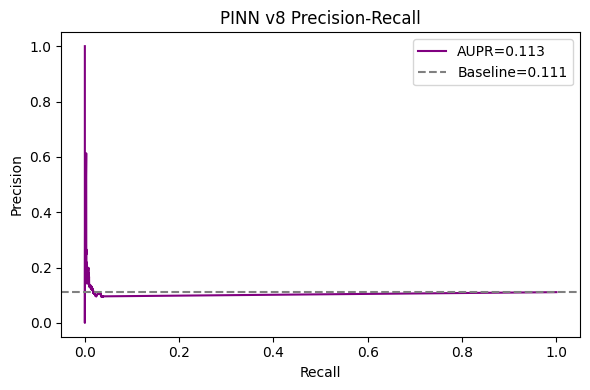

AUPR: 0.1128


In [ ]:
# 5b. Precision-Recall curve
aupr = plot_precision_recall(y_true, susceptibility, title="PINN v8 Precision-Recall")
print(f"AUPR: {aupr:.4f}")

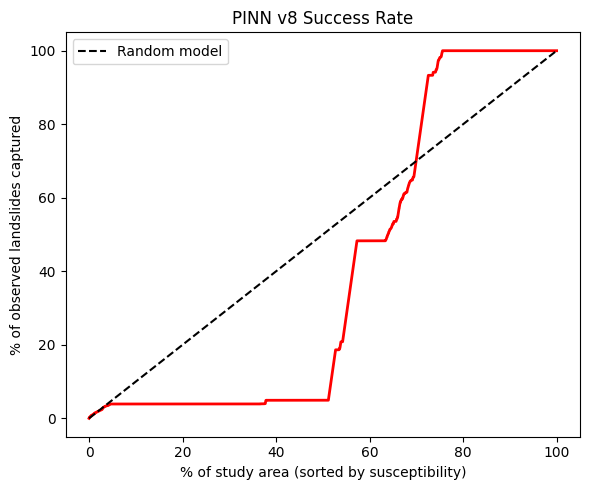

  Top 10% area captures 3.9% of landslides
  Top 20% area captures 3.9% of landslides
  Top 30% area captures 3.9% of landslides
  Top 50% area captures 4.9% of landslides


In [ ]:
# 5c. Success rate curve
pct_area, pct_ls = success_rate_curve(y_true, susceptibility, title="PINN v8 Success Rate")

In [ ]:
# 5d. Landslide density by susceptibility class
density_df = landslide_density_by_class(y_true, susceptibility, gdf=validation_df)

    class  n_slope_units  n_landslides  ls_ratio   area_km2
 Very Low          59559          6614   0.11105 811.562115
      Low              2             1   0.50000   0.020900
 Moderate              1             0   0.00000   0.016593
     High              0             0   0.00000        NaN
Very High              0             0   0.00000        NaN


## 6. Extract Intermediate Physics Parameters

In [ ]:
# Extract all intermediate outputs
fos_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("fos_layer").output)
predicted_fos = fos_model.predict(validation_ds).flatten()

cohesion_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("cohesion_layer").output)
predicted_cohesion = cohesion_model.predict(validation_ds).flatten()

ifi_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("internal_friction").output)
predicted_ifi = ifi_model.predict(validation_ds).flatten()

wetness_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("m_clip").output)
predicted_wetness = wetness_model.predict(validation_ds).flatten()

displacement_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("displacement_layer").output)
predicted_displacement = displacement_model.predict(validation_ds).flatten()

print(f"FOS:          mean={predicted_fos.mean():.4f}, std={predicted_fos.std():.4f}")
print(f"Cohesion:     mean={predicted_cohesion.mean():.4f}, std={predicted_cohesion.std():.4f}")
print(f"IFI:          mean={predicted_ifi.mean():.4f}, std={predicted_ifi.std():.4f}")
print(f"Wetness:      mean={predicted_wetness.mean():.4f}, std={predicted_wetness.std():.4f}")
print(f"Displacement: mean={predicted_displacement.mean():.4f}, std={predicted_displacement.std():.4f}")

466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step
466/466 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step
466/466 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step
466/466 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step
466/466 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step
FOS:          mean=846.0925, std=857.1213
Cohesion:     mean=11389.4355, std=10060.4580
IFI:          mean=0.9990, std=0.0177
Wetness:      mean=0.6033, std=0.0885
Displacement: mean=0.1218, std=0.0196


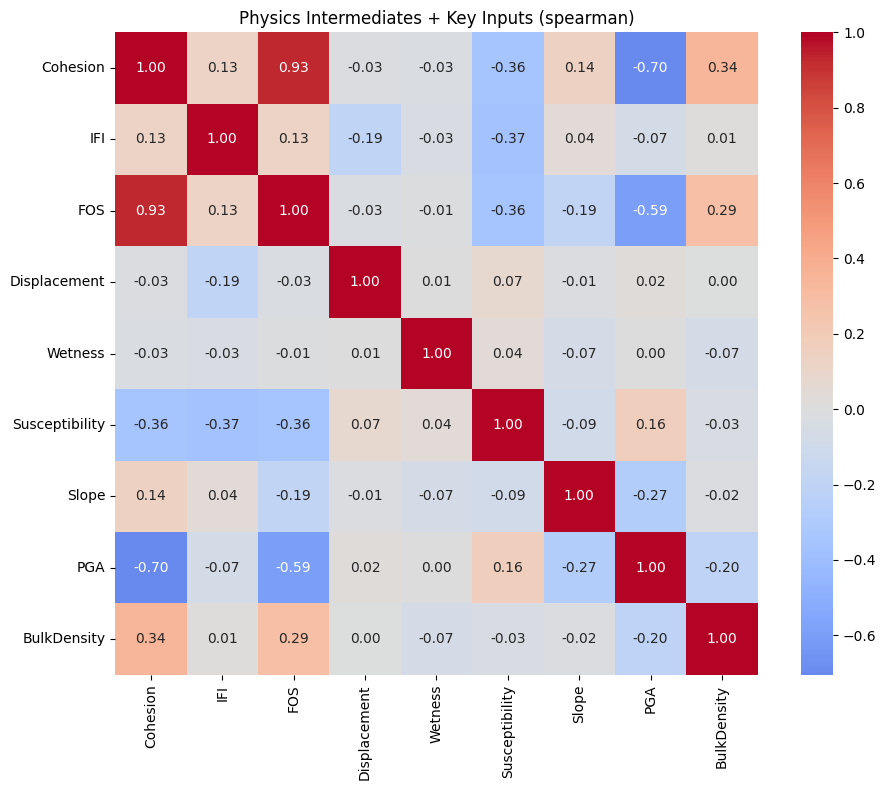

In [ ]:
# 6a. Correlation matrix of intermediate parameters + key inputs
corr_df = plot_intermediate_correlation({
    'Cohesion': predicted_cohesion,
    'IFI': predicted_ifi,
    'FOS': predicted_fos,
    'Displacement': predicted_displacement,
    'Wetness': predicted_wetness,
    'Susceptibility': susceptibility,
    'Slope': validation_df['Slope_mean'].values,
    'PGA': validation_df['PGA1_max'].values,
    'BulkDensity': validation_df['BUK_mean'].values,
}, title="Physics Intermediates + Key Inputs")

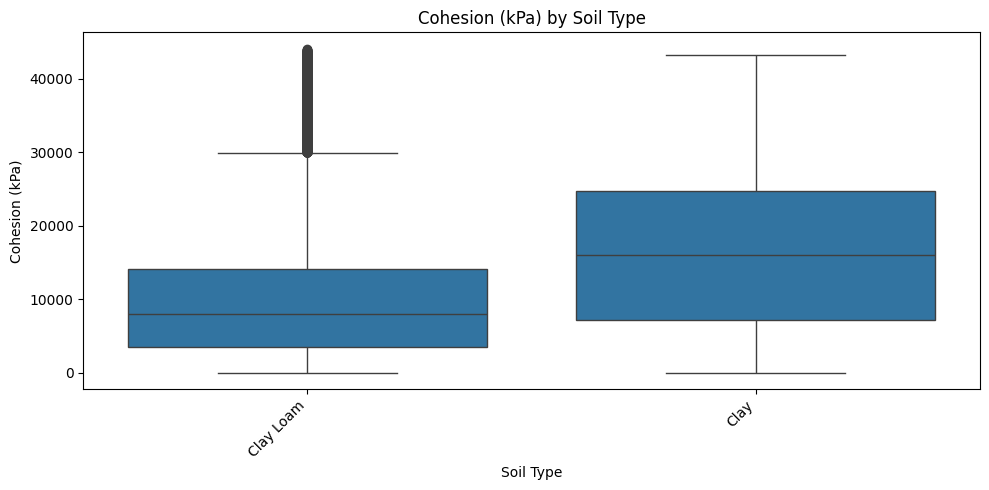

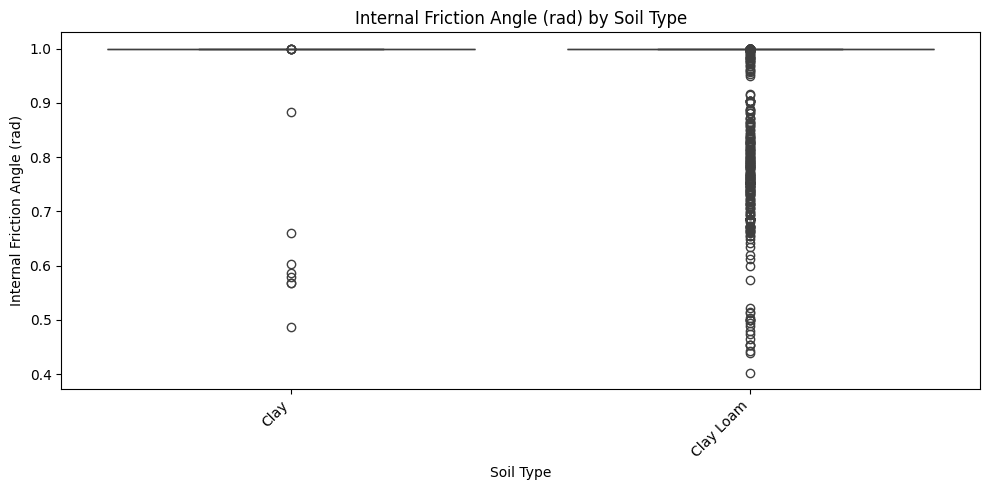

In [ ]:
# 6b. Geotechnical parameters by soil type
soil_labels = validation_df['soil_texture'].values if 'soil_texture' in validation_df.columns else validation_df['type'].values

plot_geotech_by_soil_type(predicted_cohesion, soil_labels, value_name="Cohesion (kPa)")
plot_geotech_by_soil_type(predicted_ifi, soil_labels, value_name="Internal Friction Angle (rad)")

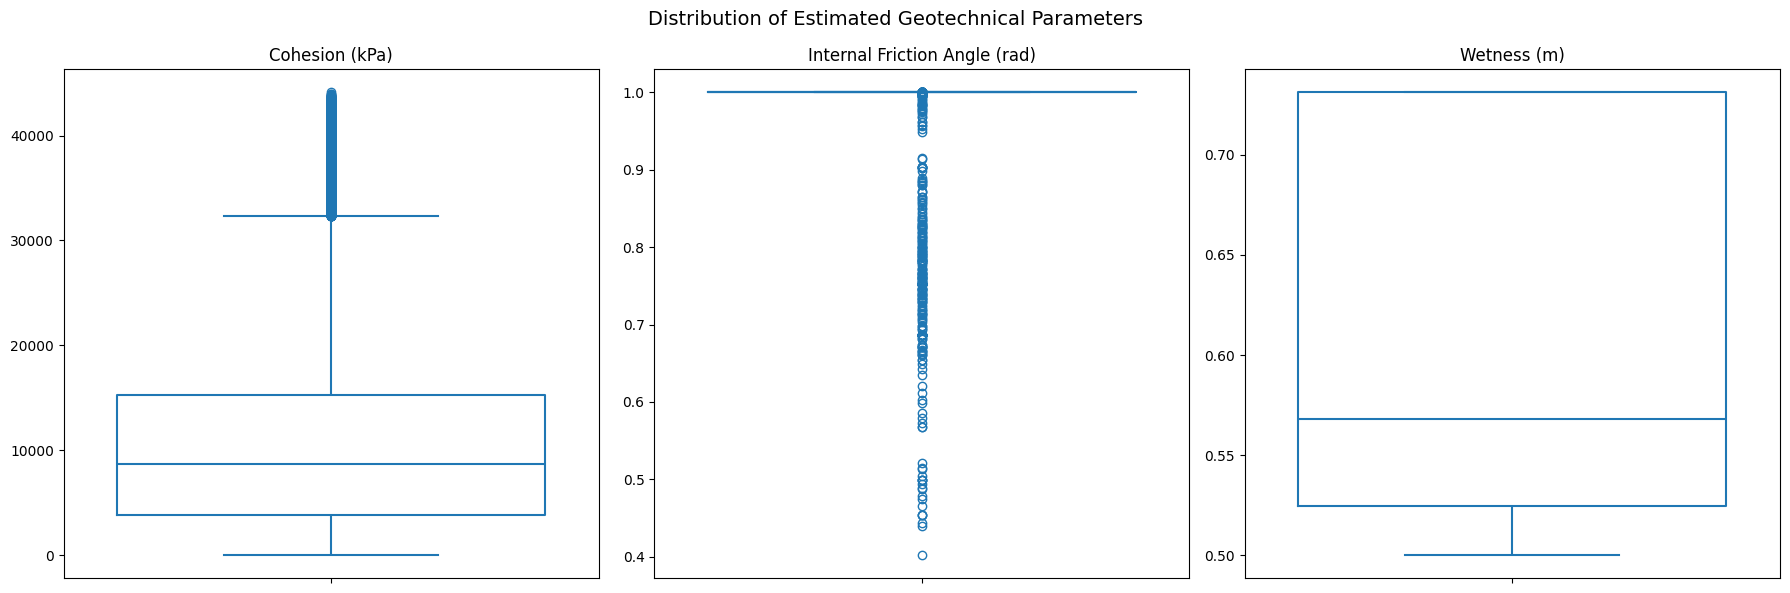

,Cohesion (kPa),Int. Friction (rad),Wetness (m)
count,59562.000000,59562.000000,59562.000000
mean,11389.435547,0.998975,0.603326
std,10060.541992,0.017669,0.088474
min,0.000000,0.402189,0.500166
25%,3816.858398,1.000000,0.524450
50%,8685.929199,1.000000,0.567955
75%,15228.874756,1.000000,0.731059
max,44106.703125,1.000000,0.731059


In [ ]:
# Geotechnical parameter boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Distribution of Estimated Geotechnical Parameters", fontsize=14)

sns.boxplot(data=predicted_cohesion, ax=axes[0], fill=False)
axes[0].set_title("Cohesion (kPa)")

sns.boxplot(data=predicted_ifi, ax=axes[1], fill=False)
axes[1].set_title("Internal Friction Angle (rad)")

sns.boxplot(data=predicted_wetness, ax=axes[2], fill=False)
axes[2].set_title("Wetness (m)")

fig.tight_layout()
plt.show()

geotech_summary = pd.DataFrame({
    'Cohesion (kPa)': predicted_cohesion,
    'Int. Friction (rad)': predicted_ifi,
    'Wetness (m)': predicted_wetness,
})
geotech_summary.describe()

## 7. Cross-Fold Stability & Ensemble Uncertainty

In [ ]:
# Load all 5 fold models and collect predictions
fold_susceptibilities = []
fold_cohesions = []
fold_ifis = []
fold_fos_list = []

for fold in range(1, 6):
    fold_path = f"{MODEL_SAVE_PATH}/fold-{fold}-model-v3.keras"
    if not os.path.exists(fold_path):
        print(f"  Fold {fold} not found at {fold_path}, skipping")
        continue
    fold_model = load_model(fold_path, custom_objects={"NewmarkActivation": NewmarkActivation})

    fold_susceptibilities.append(fold_model.predict(validation_ds)["final_head"].flatten())

    coh_m = tf.keras.Model(inputs=fold_model.inputs, outputs=fold_model.get_layer("cohesion_layer").output)
    fold_cohesions.append(coh_m.predict(validation_ds).flatten())

    ifi_m = tf.keras.Model(inputs=fold_model.inputs, outputs=fold_model.get_layer("internal_friction").output)
    fold_ifis.append(ifi_m.predict(validation_ds).flatten())

    fos_m = tf.keras.Model(inputs=fold_model.inputs, outputs=fold_model.get_layer("fos_layer").output)
    fold_fos_list.append(fos_m.predict(validation_ds).flatten())

    del fold_model
    tf.keras.backend.clear_session()

print(f"Loaded {len(fold_susceptibilities)} fold models")

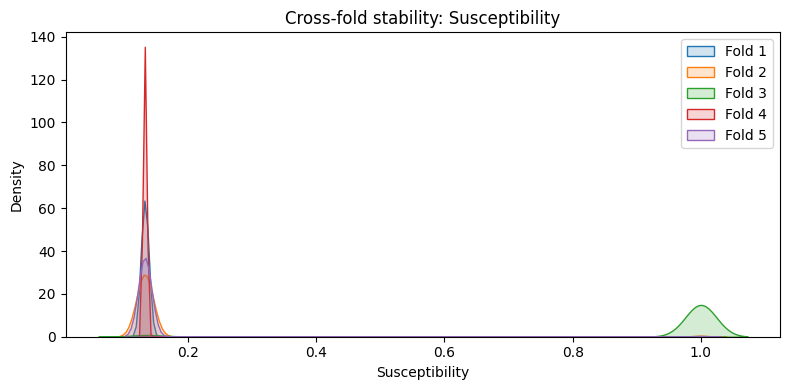

/Users/giogonzales/Documents/ml-prep/mlprep/py_files/metrics.py:379: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals.flatten(), ax=ax, label=f"Fold {i+1}", fill=True, alpha=0.2)


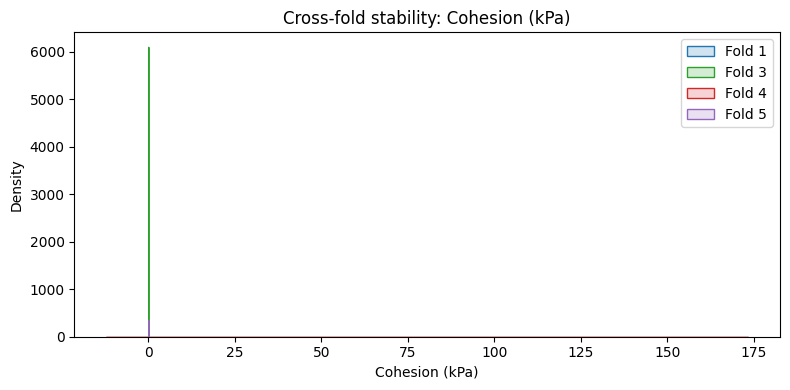

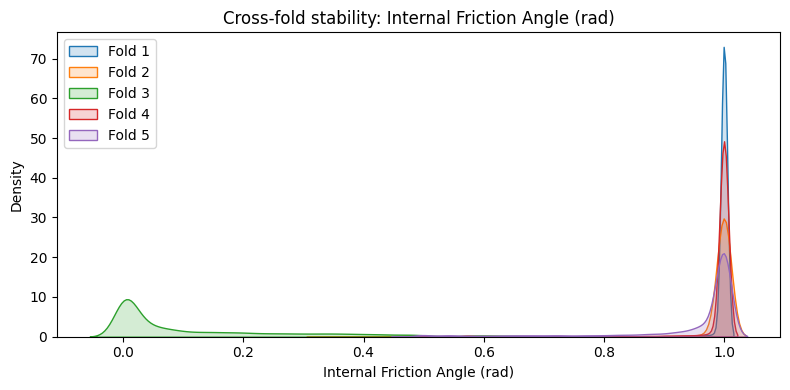

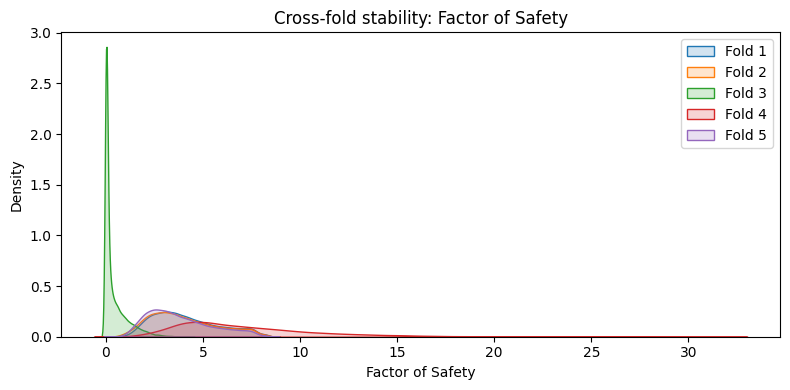

In [ ]:
# Cross-fold stability KDE plots
plot_fold_stability(fold_susceptibilities, param_name="Susceptibility")
plot_fold_stability(fold_cohesions, param_name="Cohesion (kPa)")
plot_fold_stability(fold_ifis, param_name="Internal Friction Angle (rad)")
plot_fold_stability(fold_fos_list, param_name="Factor of Safety")

Ensemble mean susceptibility: 0.3001 +/- 0.3235


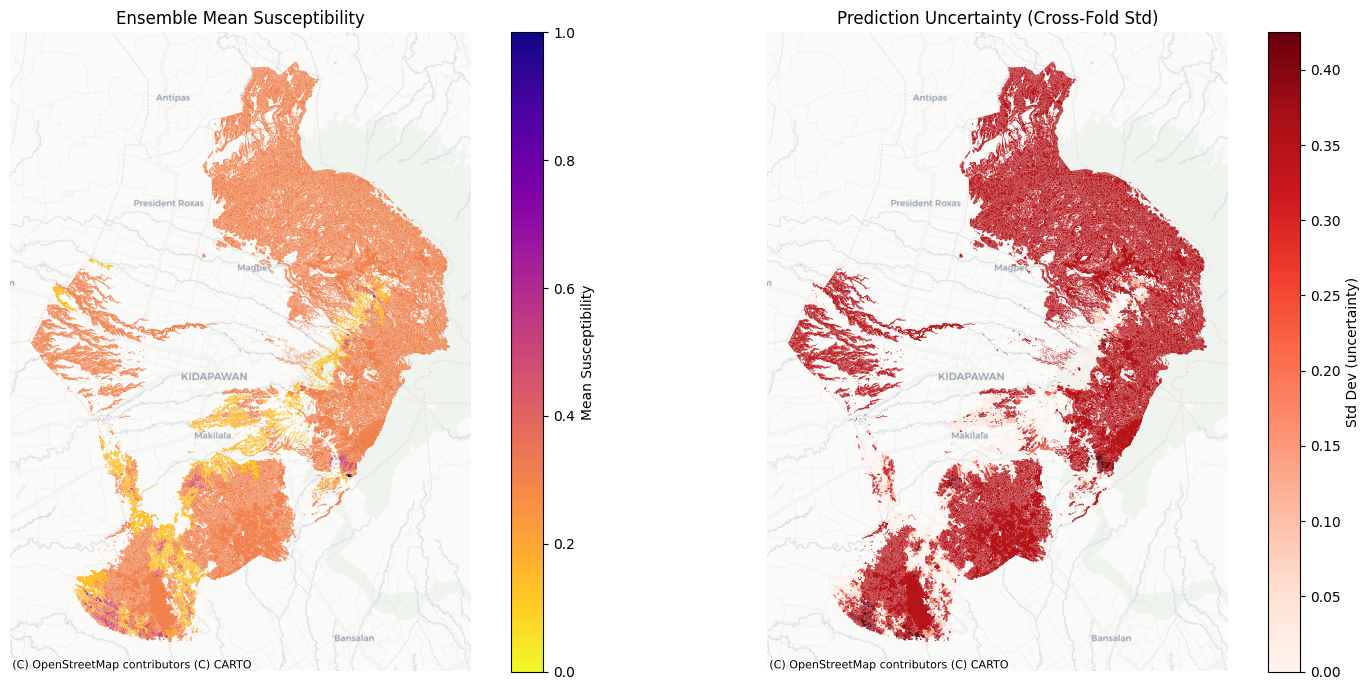

In [ ]:
# Ensemble uncertainty map
mean_sus, std_sus = fold_ensemble_uncertainty(fold_susceptibilities)
print(f"Ensemble mean susceptibility: {mean_sus.mean():.4f} +/- {std_sus.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

df_wm = validation_df.to_crs(epsg=3857)
df_wm['ensemble_mean'] = mean_sus
df_wm['ensemble_std'] = std_sus

norm_sus = mcolors.Normalize(vmin=0, vmax=1.0)
df_wm.plot(column='ensemble_mean', cmap='plasma_r', norm=norm_sus, ax=axes[0],
           legend=True, legend_kwds={'label': 'Mean Susceptibility'})
cx.add_basemap(axes[0], crs=df_wm.crs.to_string(), source=cx.providers.CartoDB.Positron)
axes[0].set_title('Ensemble Mean Susceptibility')
axes[0].set_axis_off()

norm_std = mcolors.Normalize(vmin=0, vmax=std_sus.max())
df_wm.plot(column='ensemble_std', cmap='Reds', norm=norm_std, ax=axes[1],
           legend=True, legend_kwds={'label': 'Std Dev (uncertainty)'})
cx.add_basemap(axes[1], crs=df_wm.crs.to_string(), source=cx.providers.CartoDB.Positron)
axes[1].set_title('Prediction Uncertainty (Cross-Fold Std)')
axes[1].set_axis_off()

fig.tight_layout()
plt.show()

## 8. SHAP Feature Importance

In [ ]:
import shap
from py_files.metrics import compute_shap_values, plot_shap_summary

shap_feature_cols = [c for c in columns + ['soil_texture_idx'] if c != 'landslide']

shap_values, shap_data, shap_feature_names = compute_shap_values(
    model, validation_df, shap_feature_cols,
    n_background=200, n_explain=500
)

/Users/giogonzales/Documents/ml-prep/mlprep/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
  0%|          | 0/500 [00:00<?, ?it/s]/Users/giogonzales/Documents/ml-prep/mlprep/venv/lib/python3.12/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/giogonzales/Documents/ml-prep/mlprep/venv/lib/python3.12/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/giogonzales/Documents/ml-prep/mlprep/venv/lib/python3.12/site-packages/shap/explainers/_kernel.py:706

/var/folders/dz/wrg2699d4jq7zd26swc8s2wm0000gn/T/ipykernel_12154/4170192243.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_data, feature_names=shap_feature_names)


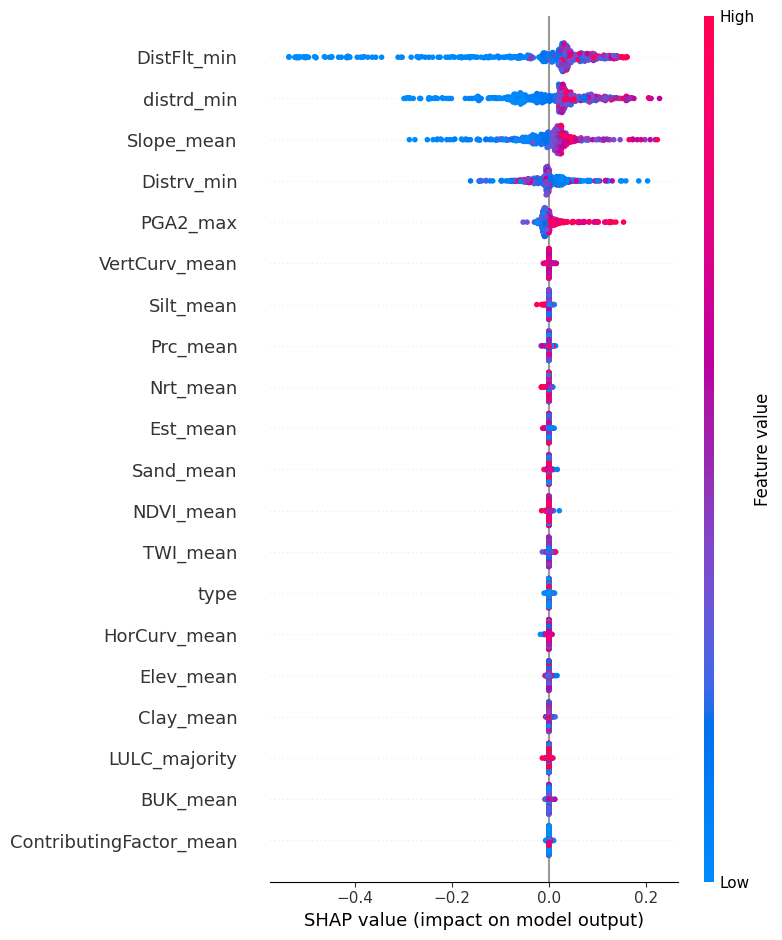

In [ ]:
# SHAP beeswarm plot
shap.summary_plot(shap_values, shap_data, feature_names=shap_feature_names)

/var/folders/dz/wrg2699d4jq7zd26swc8s2wm0000gn/T/ipykernel_12154/3189879323.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_data, feature_names=shap_feature_names, plot_type="bar")


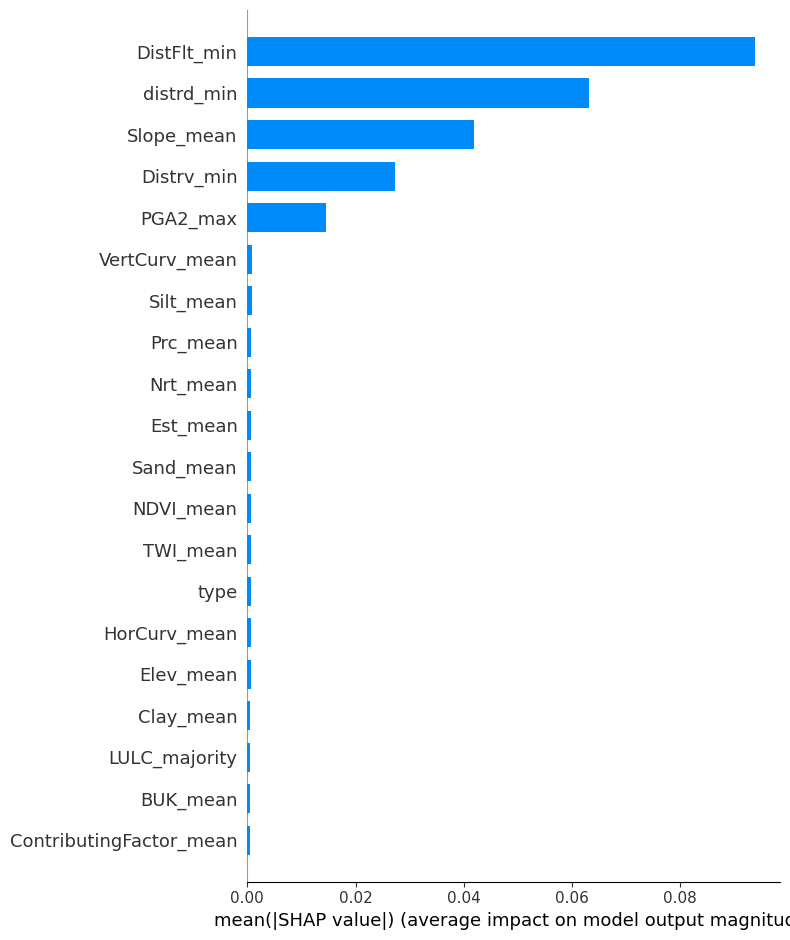

In [ ]:
# SHAP bar plot
shap.summary_plot(shap_values, shap_data, feature_names=shap_feature_names, plot_type="bar")

In [ ]:
# Feature importance table ranked by mean |SHAP|
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
importance_df = pd.DataFrame({
    'feature': shap_feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)
importance_df

,feature,mean_abs_shap
11,DistFlt_min,0.093774
17,distrd_min,0.063149
8,Slope_mean,0.041901
16,Distrv_min,0.027259
14,PGA2_max,0.014610
7,VertCurv_mean,0.000814
2,Silt_mean,0.000803
15,Prc_mean,0.000746
5,Nrt_mean,0.000733
4,Est_mean,0.000699


## 9. Hydraulic Conductivity (Learned vs Literature)

In [ ]:
layer = model.get_layer("hydraulic_conductivity_v3")

u_k = layer.u_k.numpy()
k_min = layer.k_min.numpy()
k_max = layer.k_max.numpy()
k_cmh = k_min + (k_max - k_min) * tf.nn.sigmoid(u_k).numpy()

soil_names = [
    "Sand", "Loamy Sand", "Sandy Loam", "Silt Loam", "Loam", "Silt",
    "Sandy Clay Loam", "Clay Loam", "Silty Clay Loam", "Sandy Clay",
    "Silty Clay", "Clay",
]

k_df = pd.DataFrame({
    'Soil Type': soil_names,
    'K_learned (cm/h)': k_cmh,
    'K_min (cm/h)': k_min,
    'K_max (cm/h)': k_max,
})
k_df

,Soil Type,K_learned (cm/h),K_min (cm/h),K_max (cm/h)
0,Sand,420.505005,0.01,841.000000
1,Loamy Sand,94.505005,0.01,189.000000
2,Sandy Loam,252.000000,0.00,504.000000
3,Silt Loam,26.950001,0.00,53.900002
4,Loam,26.440052,0.01,52.599998
5,Silt,106.634995,0.27,213.000000
6,Sandy Clay Loam,202.500000,0.00,405.000000
7,Clay Loam,19.295626,0.01,38.200001
8,Silty Clay Loam,79.505005,0.01,159.000000
9,Sandy Clay,30.299999,0.00,60.599998


## 10. Incomplete Inventory Validation (False Positive Analysis)

The landslide inventory covers only a single earthquake event. Slope units labeled "no landslide" may actually be genuinely susceptible areas that weren't captured. This section tests whether the model's "false positives" share geomorphological characteristics with known landslide sites — evidence of correct generalization rather than overprediction.

In [ ]:
# 10a. Classify predictions into TP / FP / TN / FN and summarize
GEOMORPH_FEATURES = [
    'Slope_mean', 'Elev_mean', 'Prc_mean', 'TWI_mean',
    'SoilThc_mean', 'BUK_mean', 'ContributingFactor_mean',
    'DistFlt_min', 'NDVI_mean', 'Distrv_min', 'distrd_min',
]
# Keep only features that exist in validation_df
geomorph_cols = [c for c in GEOMORPH_FEATURES if c in validation_df.columns]

summary, cats = false_positive_analysis(
    validation_df, susceptibility, geomorph_cols, threshold=0.5
)

Sample counts per group:
_group
FP    48684
TP     6374
TN     4263
FN      241

Mean feature values by group:
        Slope_mean  Elev_mean  Prc_mean  TWI_mean  SoilThc_mean  BUK_mean  ContributingFactor_mean  DistFlt_min  NDVI_mean  Distrv_min  distrd_min
_group                                                                                                                                            
FN         18.7347   429.5742  199.7224    3.2462       17.4096   11.1172               26000.8339     270.3170     0.7346     59.4539     55.7147
FP         23.3725   734.7577  220.9588    3.2074       13.4612   11.3617               28531.8032    6556.6804     0.7644    522.9089    519.1498
TN         15.6402   442.4290  211.3296    3.5045       14.2963   11.2300               13216.3106     454.3136     0.7726    120.5601    117.2704
TP         28.8983   729.3432  203.2536    2.9516       13.8607   11.4674               18903.8740    3591.1897     0.7618    608.5293    600.2034


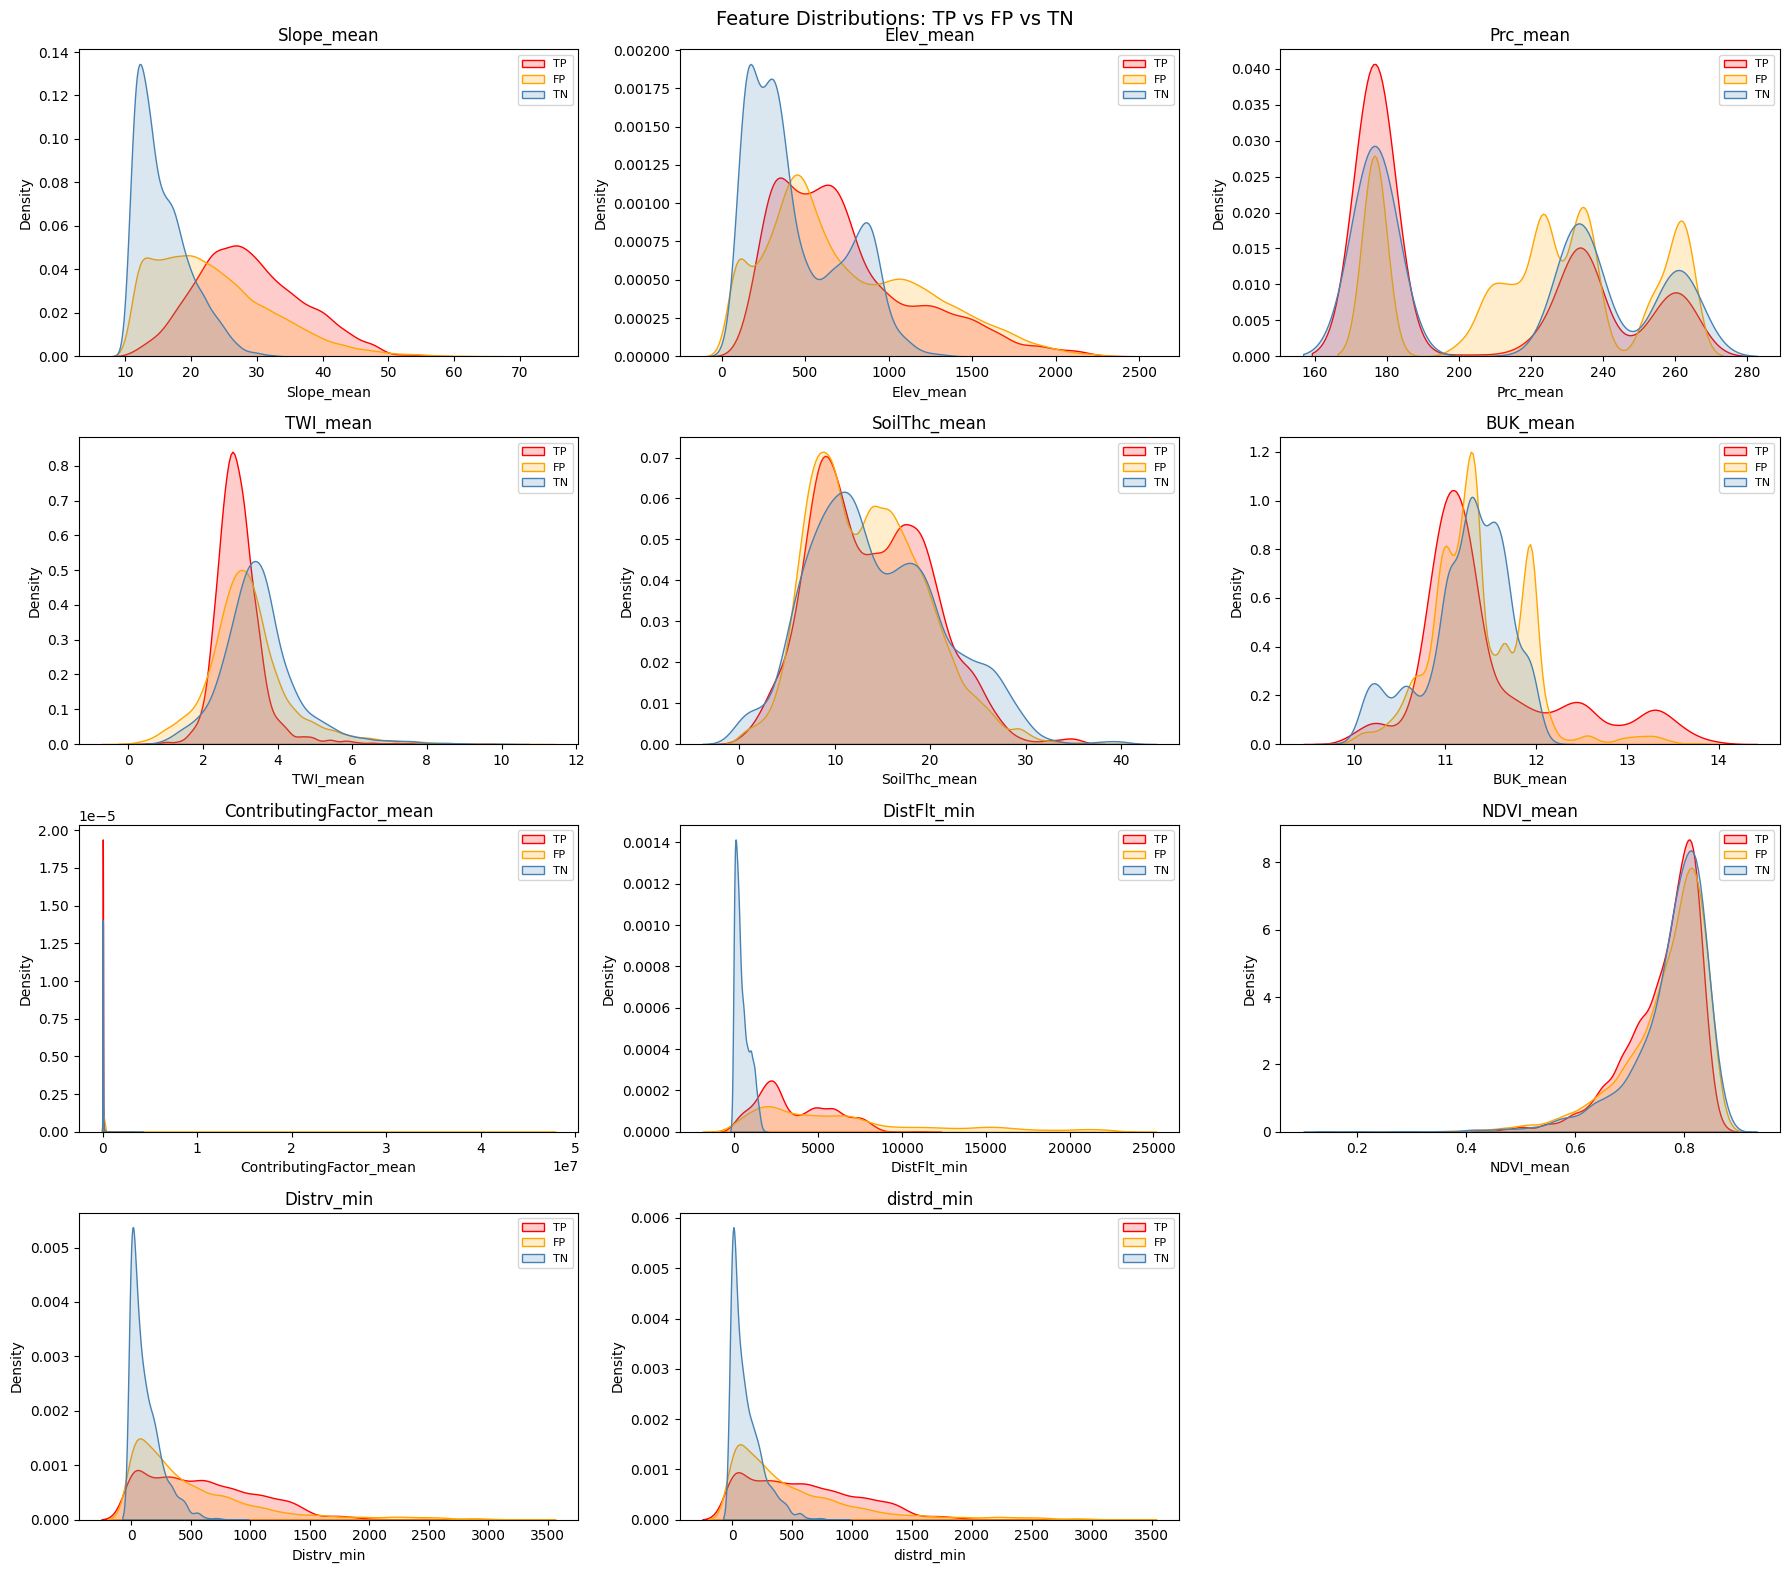

In [ ]:
# 10b. KDE distribution plots — TP vs FP vs TN
# Overlapping TP and FP curves (both distinct from TN) = model finds real susceptible areas
plot_fp_vs_tp_distributions(validation_df, cats, geomorph_cols, ncols=3)

In [ ]:
# 10c. Mann-Whitney U statistical tests
# FP vs TP: p > 0.05 → FP are statistically similar to known landslides
# FP vs TN: p < 0.05 → FP are distinct from stable areas (not random noise)
test_results = fp_tp_statistical_tests(validation_df, cats, geomorph_cols)


Mann-Whitney U tests (FP characterization):
                feature  FP_vs_TP_U    FP_vs_TP_p FP_similar_to_TP  FP_vs_TN_U    FP_vs_TN_p FP_differs_from_TN
             Slope_mean  94691491.0  0.000000e+00               No 162468565.5  0.000000e+00                Yes
              Elev_mean 153059596.0  7.894446e-02              Yes 142901170.0  0.000000e+00                Yes
               Prc_mean 198844605.5 1.203379e-299               No 117636528.0  2.166519e-48                Yes
               TWI_mean 179680178.0  7.248044e-94               No  82731554.0 4.002991e-107                Yes
           SoilThc_mean 148843955.5  1.224357e-07               No  97424974.5  3.346056e-11                Yes
               BUK_mean 161545463.0  8.562406e-08               No 112241544.5  8.535464e-19                Yes
ContributingFactor_mean 108305944.0  0.000000e+00               No 107768095.0  2.940148e-05                Yes
            DistFlt_min 200614902.0  0.000000e+00          

/Users/giogonzales/Documents/ml-prep/mlprep/py_files/metrics.py:561: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Group", loc="upper right")
/Users/giogonzales/Documents/ml-prep/mlprep/py_files/metrics.py:561: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Group", loc="upper right")


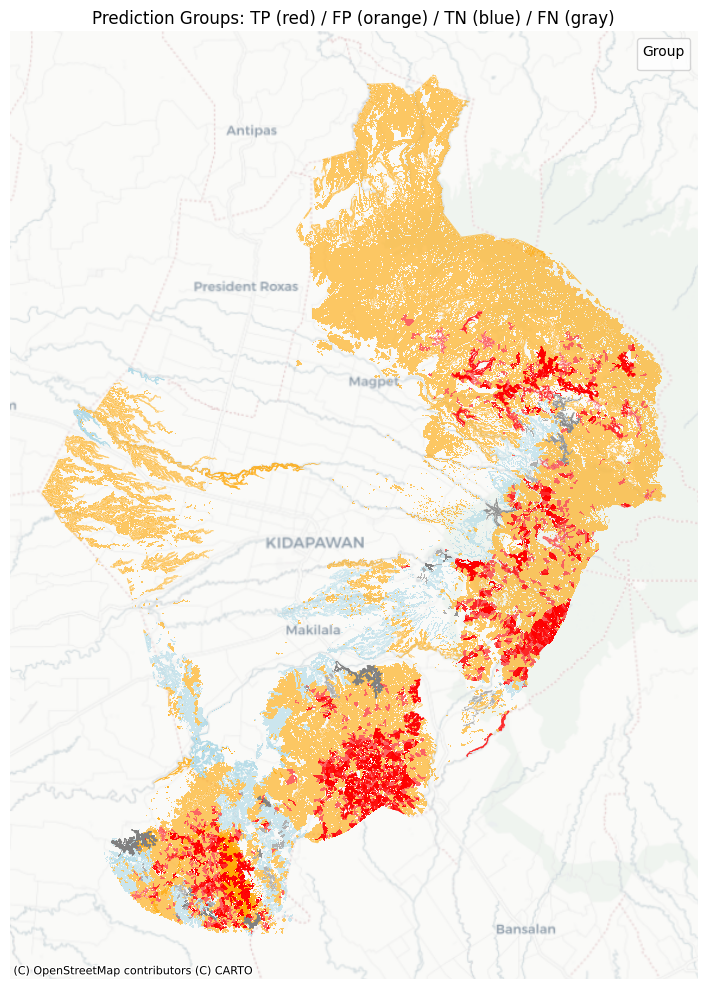

In [ ]:
# 10d. Spatial map — where are false positives located?
# Orange (FP) clustering near red (TP) = spatially coherent, not random noise
plot_fp_map(validation_df, cats, title="Prediction Groups: TP (red) / FP (orange) / TN (blue) / FN (gray)")

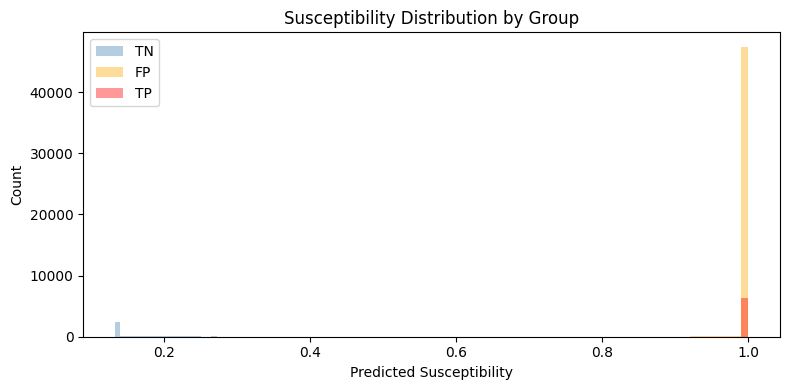

In [ ]:
# 10e. Susceptibility histogram by group
plot_fp_susceptibility_histogram(susceptibility, cats)

=== Physics Intermediate Means by Group ===
           FOS  Displacement  Cohesion     IFI  Wetness
_group                                                 
FN      1.9514      0.475100    0.0013  0.5602   0.4692
FP      0.2664  39090.972656    0.0000  0.0934   0.3402
TN      2.0800      0.447100    0.0002  0.5080   0.3829
TP      0.2692  40172.011719    0.0000  0.1196   0.4274


/var/folders/dz/wrg2699d4jq7zd26swc8s2wm0000gn/T/ipykernel_12154/4103501722.py:27: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pvals[mask], ax=ax, label=grp, color=colors[grp],


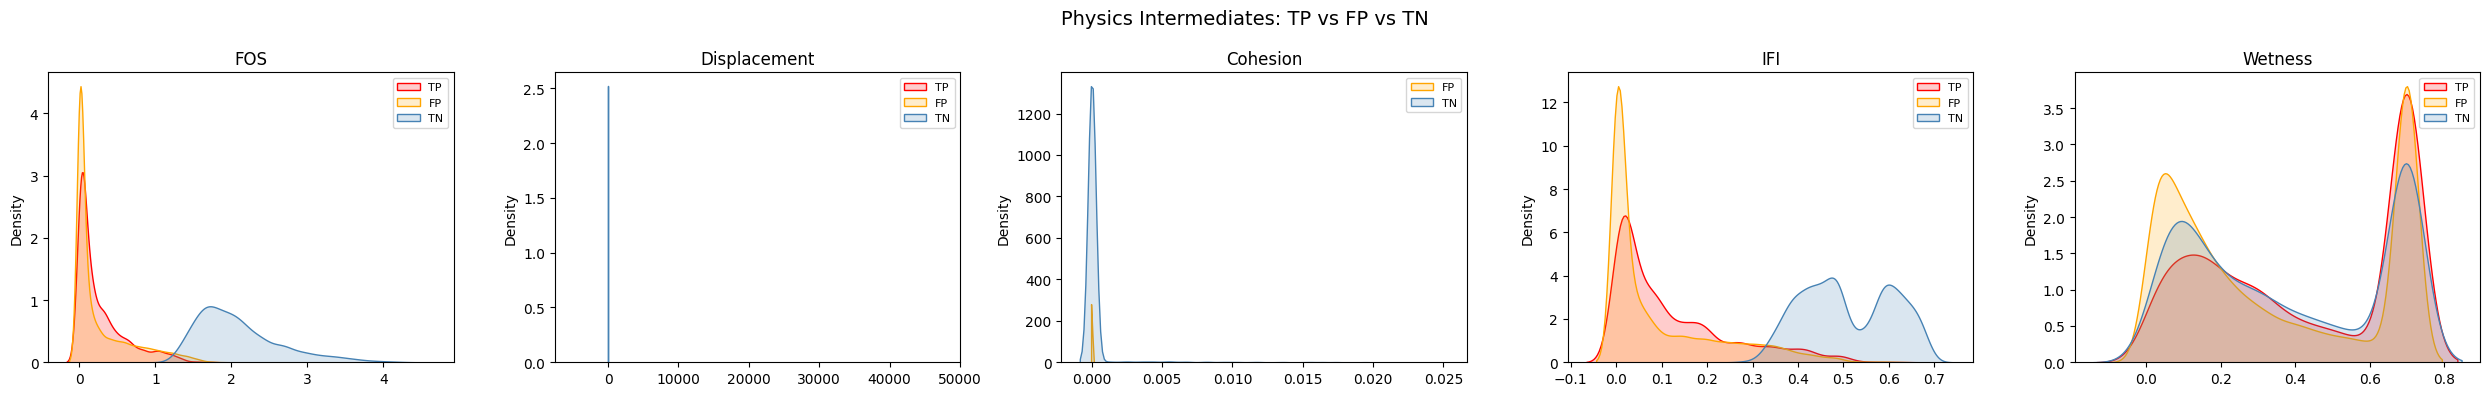

In [ ]:
# 10f. Physics intermediate comparison — FP vs TP
# If FOS, displacement, cohesion are similar between FP and TP,
# the geotechnical reasoning is consistent (not just surface pattern-matching)
physics_cols = {
    'FOS': predicted_fos,
    'Displacement': predicted_displacement,
    'Cohesion': predicted_cohesion,
    'IFI': predicted_ifi,
    'Wetness': predicted_wetness,
}
physics_df = pd.DataFrame(physics_cols)
physics_df['_group'] = cats

print("=== Physics Intermediate Means by Group ===")
print(physics_df.groupby('_group')[list(physics_cols.keys())].mean().round(4).to_string())

# KDE comparison for physics intermediates
groups_to_plot = ["TP", "FP", "TN"]
colors = {"TP": "red", "FP": "orange", "TN": "steelblue"}
fig, axes = plt.subplots(1, len(physics_cols), figsize=(5 * len(physics_cols), 4))

for i, (pname, pvals) in enumerate(physics_cols.items()):
    ax = axes[i]
    for grp in groups_to_plot:
        mask = cats == grp
        if mask.sum() > 1:
            sns.kdeplot(pvals[mask], ax=ax, label=grp, color=colors[grp],
                        fill=True, alpha=0.2)
    ax.set_title(pname)
    ax.legend(fontsize=8)

fig.suptitle("Physics Intermediates: TP vs FP vs TN", fontsize=14)
fig.tight_layout()
plt.show()